In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import VotingClassifier, BaggingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from skimage.feature import hog
from skimage import color
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model

In [4]:
# from google.colab import drive
# drive.mount('/content/drive')

# import zipfile

# zip_path = "/content/drive/MyDrive/viechle.zip"
# extract_path = "/content/dataset_v"

# if not os.path.exists(extract_path):
#     with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#         zip_ref.extractall(extract_path)

BASE = "/mnt/d/Ai journey/Assignments/German-signs"

train_dir = os.path.join(BASE, 'Train')
filepaths, labels = [], []

for folder in os.listdir(train_dir):
    foldpath = os.path.join(train_dir, folder)
    if os.path.isdir(foldpath):
        for file in os.listdir(foldpath):
            filepaths.append(os.path.join(foldpath, file))
            labels.append(int(folder))

train_df = pd.DataFrame({
    'filepath': filepaths,
    'label': labels
})

test_csv_path = os.path.join(BASE, 'Test.csv')
test_csv = pd.read_csv(test_csv_path)

test_df = pd.DataFrame({
    'filepath': test_csv['Path'].apply(lambda p: os.path.join(BASE, p)),
    'label': test_csv['ClassId'].astype(int)
})

print("Train size:", len(train_df))
print("Test size:", len(test_df))

Train size: 39209
Test size: 12630


DIVIDE THE Train df

In [6]:
train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df['label']   
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print(f"Train size : {len(train_df)}")
print(f"Val size : {len(val_df)}")
print(f"Test size : {len(test_df)}")

Train size : 25093
Val size : 6274
Test size : 12630


In [7]:
CLASS_NAMES = {
    0:'Speed limit 20',    1:'Speed limit 30',     2:'Speed limit 50',
    3:'Speed limit 60',    4:'Speed limit 70',     5:'Speed limit 80',
    6:'End speed 80',      7:'Speed limit 100',    8:'Speed limit 120',
    9:'No passing',       10:'No passing >3.5t',  11:'Right of way jn.',
   12:'Priority road',    13:'Yield',              14:'Stop',
   15:'No vehicles',      16:'No veh >3.5t',      17:'No entry',
   18:'General caution',  19:'Danger curve L',     20:'Danger curve R',
   21:'Double curve',     22:'Bumpy road',         23:'Slippery road',
   24:'Narrow road R',    25:'Road works',         26:'Traffic signals',
   27:'Pedestrians',      28:'Children crossing',  29:'Bicycles crossing',
   30:'Beware of ice',    31:'Wild animals',       32:'End restrictions',
   33:'Turn right ahead', 34:'Turn left ahead',    35:'Ahead only',
   36:'Ahead or right',   37:'Ahead or left',      38:'Keep right',
   39:'Keep left',        40:'Roundabout',         41:'End no passing',
   42:'End no pass >3.5t'
}

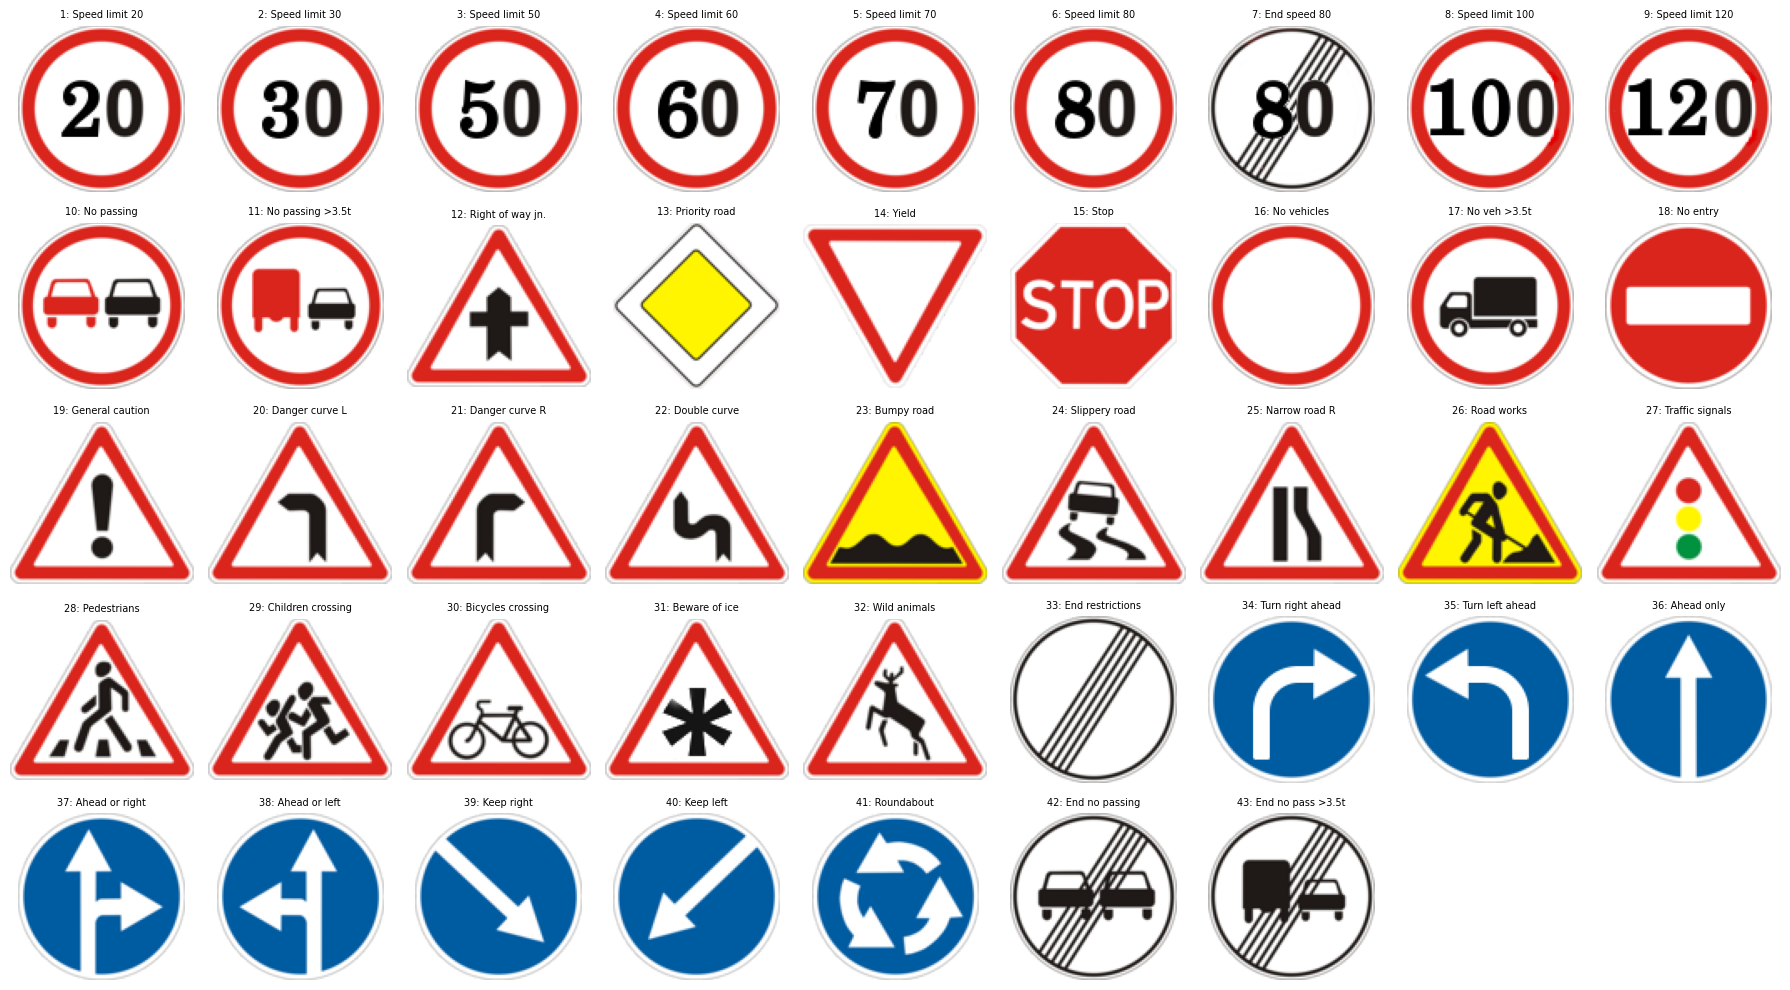

In [17]:
meta_path = os.path.join(BASE, "Meta")

fig, axes = plt.subplots(5, 9, figsize=(18, 10))
axes = axes.flatten()

for class_id in range(43):
    img_path = os.path.join(meta_path, f"{class_id}.png")
    img = Image.open(img_path)

    axes[class_id].imshow(img)
    axes[class_id].set_title(f"{class_id+1}: {CLASS_NAMES[class_id]}", fontsize=7)
    axes[class_id].axis("off")


for i in range(43, len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

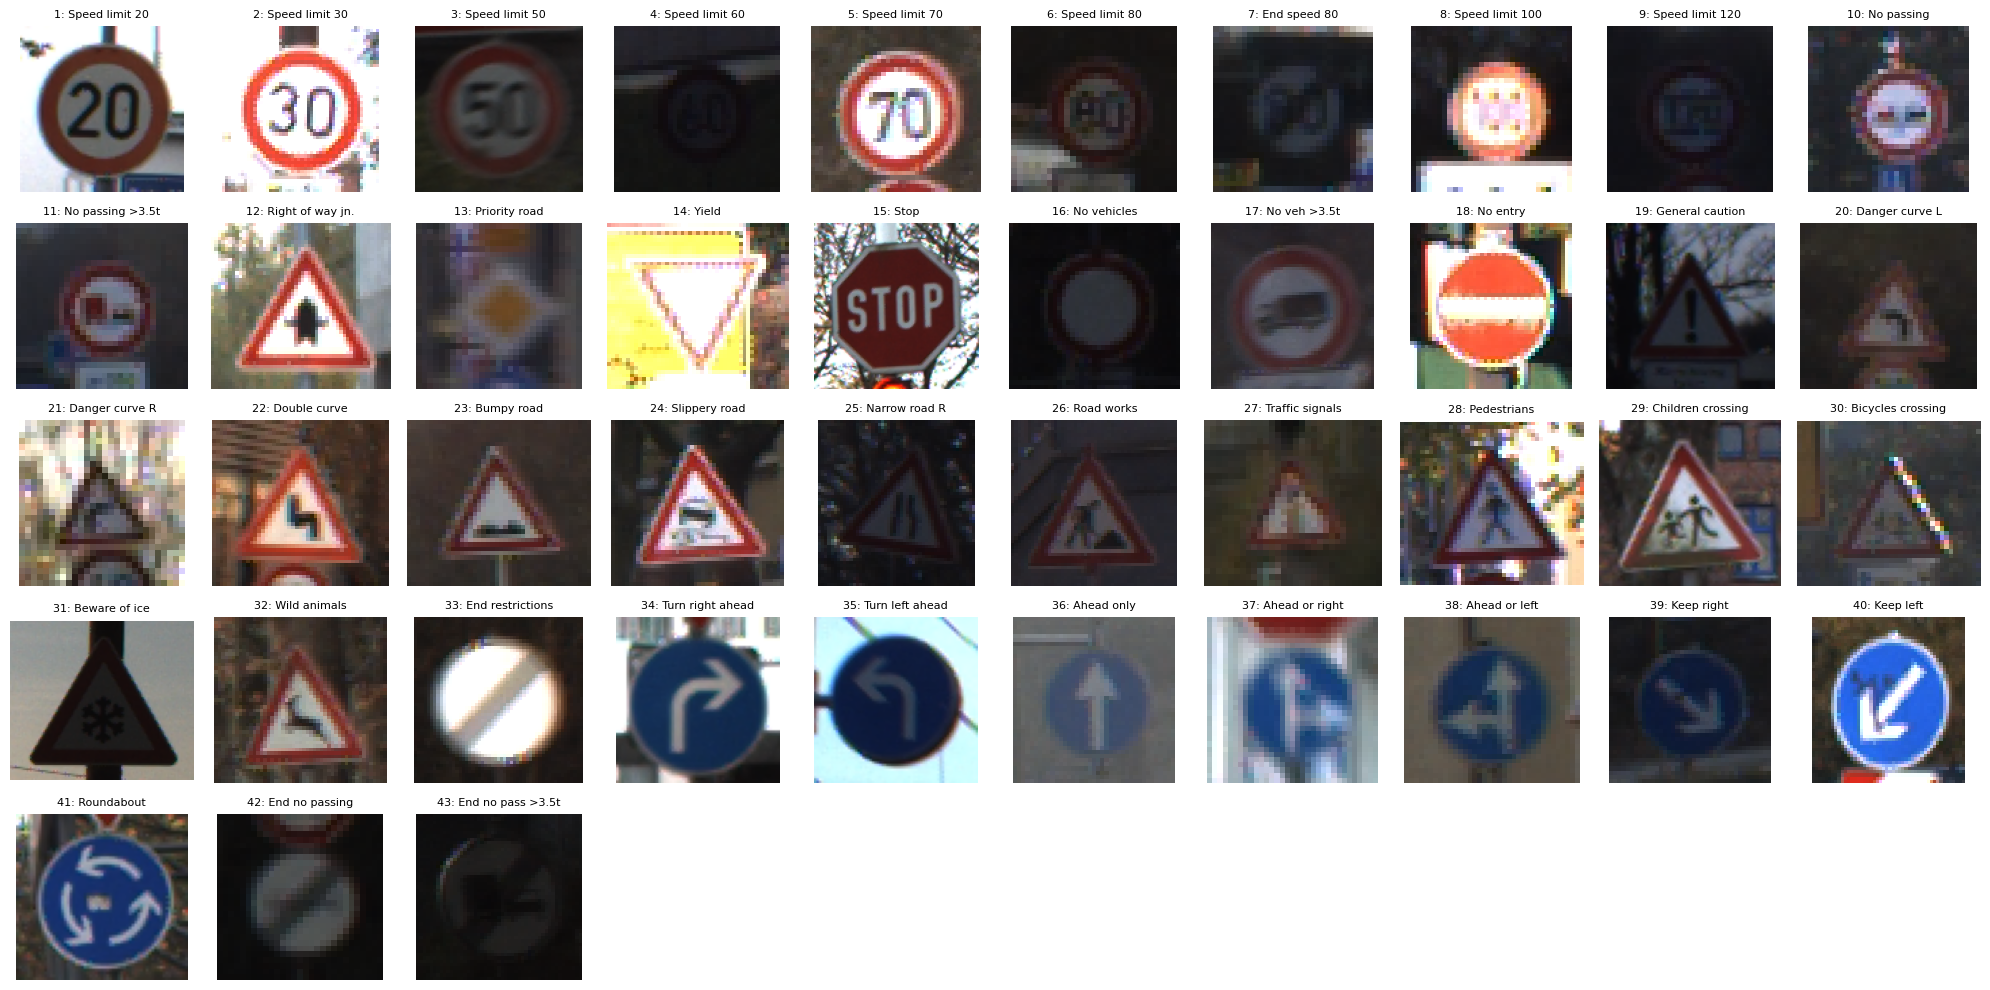

In [18]:
sample_df = train_df.groupby('label').first().reset_index()

n_samples = len(sample_df)

n_cols = 10
n_rows = (n_samples + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 10))
axes = axes.flatten()

for i in range(n_samples):
    img = Image.open(sample_df['filepath'][i])

    label = sample_df['label'][i]
    class_name = CLASS_NAMES[label]

    axes[i].imshow(img)
    axes[i].set_title(f"{label+1}: {class_name}", fontsize=8)
    axes[i].axis('off')

for i in range(n_samples, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

/tmp/ipykernel_4759/587783984.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')


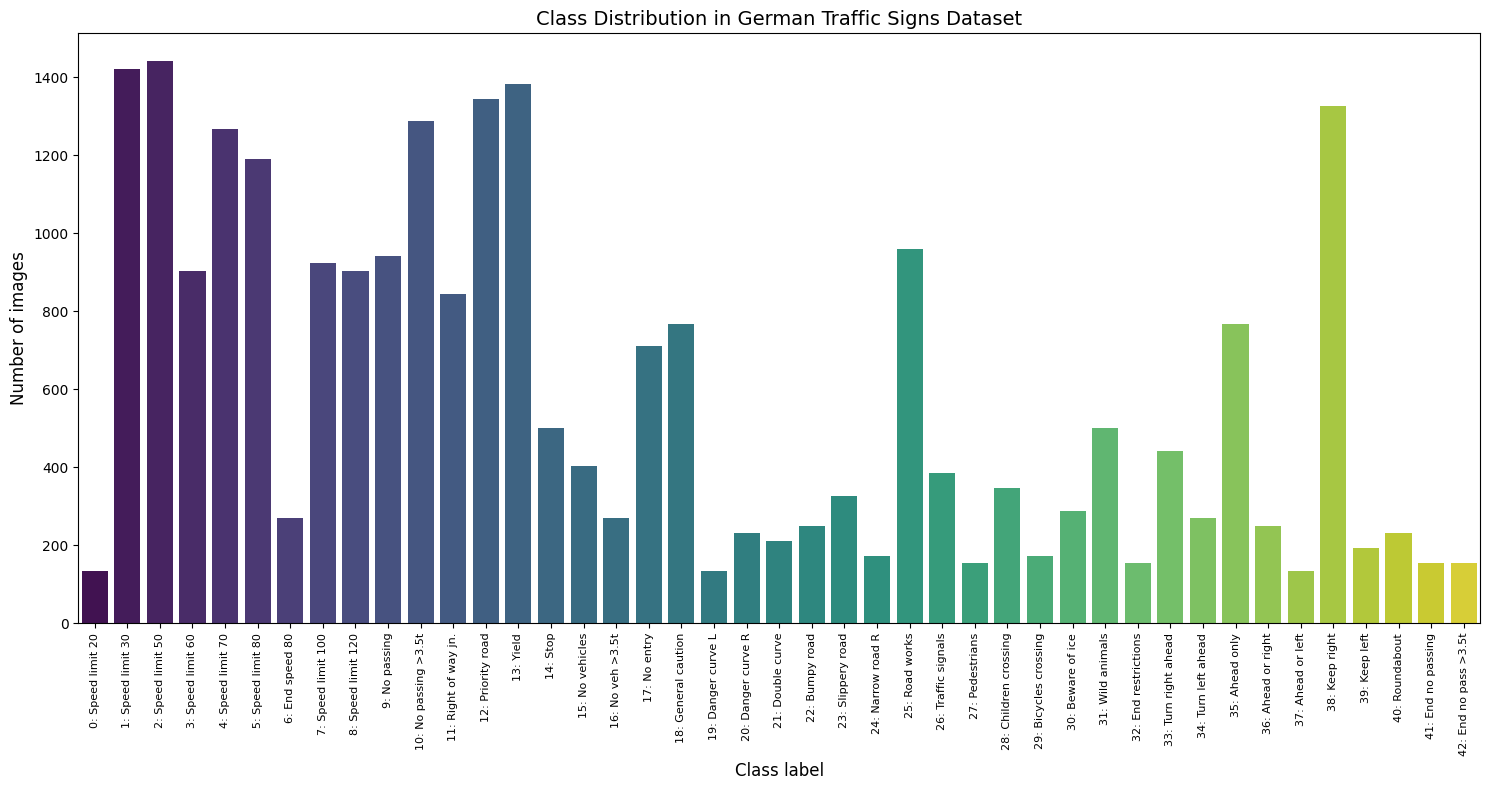

Total images: 25093
Total classes: 43
Average images per class: 583.56
Min images in a class: 134
Max images in a class: 1440


In [19]:
class_counts = train_df['label'].value_counts().sort_index()

plt.figure(figsize=(15, 8))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.xlabel('Class label', fontsize=12)
plt.ylabel('Number of images', fontsize=12)
plt.title('Class Distribution in German Traffic Signs Dataset', fontsize=14)

plt.xticks(ticks=range(len(class_counts)),
           labels=[f"{i}: {CLASS_NAMES[i]}" for i in class_counts.index],
           rotation=90, fontsize=8)

plt.tight_layout()
plt.show()

print(f"Total images: {len(train_df)}")
print(f"Total classes: {len(class_counts)}")
print(f"Average images per class: {len(train_df)/len(class_counts):.2f}")
print(f"Min images in a class: {class_counts.min()}")
print(f"Max images in a class: {class_counts.max()}")

In [24]:
def preprocess_image(image_path, size=(32, 32)):
    img = Image.open(image_path).resize(size)
    return np.array(img)

def extract_hog_features(image_array,
                          pixels_per_cell=(8, 8),
                          cells_per_block=(2, 2),
                          orientations=8):
    img_gray = color.rgb2gray(image_array)
    fd = hog(img_gray,
             orientations=orientations,
             pixels_per_cell=pixels_per_cell,
             cells_per_block=cells_per_block,
             block_norm='L2-Hys',
             transform_sqrt=True,
             feature_vector=True)
    return fd

def build_hog_features(df):
    features = []
    for filepath in df['filepath']:
        img_array = preprocess_image(filepath)
        features.append(extract_hog_features(img_array))
    return np.array(features)

x_train_hog = build_hog_features(train_df)
x_val_hog   = build_hog_features(val_df)
x_test_hog  = build_hog_features(test_df)

y_train = train_df['label'].values
y_val   = val_df['label'].values
y_test  = test_df['label'].values

print(f"HOG feature size : {x_train_hog.shape[1]}")
print(f"Train HOG : {x_train_hog.shape}")
print(f"Val HOG : {x_val_hog.shape}")
print(f"Test HOG : {x_test_hog.shape}")

HOG feature size : 288
Train HOG : (25093, 288)
Val HOG : (6274, 288)
Test HOG : (12630, 288)


In [26]:
y_train = train_df['label'].values
y_val   = val_df['label'].values
y_test  = test_df['label'].values

In [27]:
scaler = StandardScaler()
x_train_s = scaler.fit_transform(x_train_hog)
x_val_s  = scaler.transform(x_val_hog)
x_test_s  = scaler.transform(x_test_hog)

In [28]:
save_path = "features"
os.makedirs(save_path, exist_ok=True)

np.save(os.path.join(save_path, "x_train.npy"),        x_train_hog)
np.save(os.path.join(save_path, "x_val.npy"),          x_val_hog)
np.save(os.path.join(save_path, "x_test.npy"),         x_test_hog)
np.save(os.path.join(save_path, "y_train.npy"),        y_train)
np.save(os.path.join(save_path, "y_val.npy"),          y_val)
np.save(os.path.join(save_path, "y_test.npy"),         y_test)
np.save(os.path.join(save_path, "x_train_scaled.npy"), x_train_s)
np.save(os.path.join(save_path, "x_val_scaled.npy"),   x_val_s)
np.save(os.path.join(save_path, "x_test_scaled.npy"),  x_test_s)

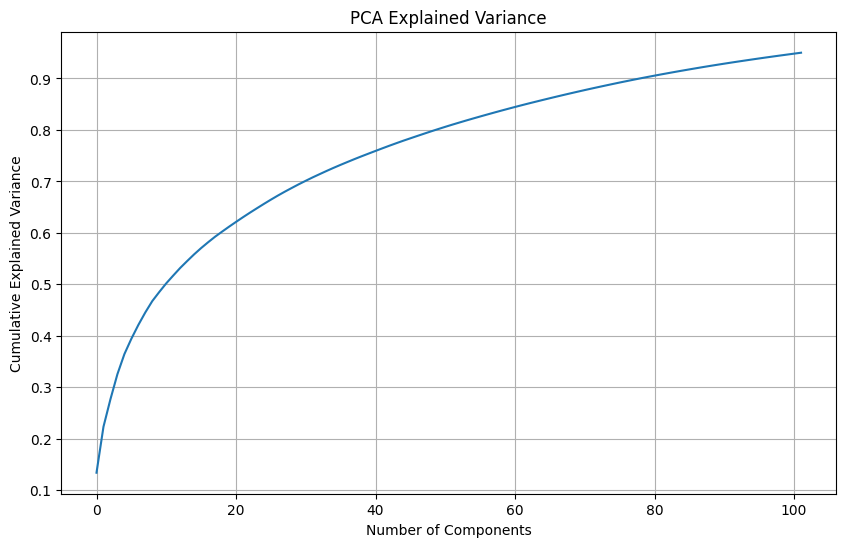

Components selected: 102


In [29]:
# Applying PCA for Dimensionality Reduction
pca = PCA(n_components=0.95)
x_train_pca = pca.fit_transform(x_train_s)
x_val_pca   = pca.transform(x_val_s)
x_test_pca  = pca.transform(x_test_s)

# Plotting the explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.grid()
plt.show()

print(f"Components selected: {pca.n_components_}")

In [28]:
print(f"PCA components selected: {pca.n_components_}")
print(f"Train PCA : {x_train_pca.shape}")
print(f"Val   PCA : {x_val_pca.shape}")
print(f"Test  PCA : {x_test_pca.shape}")

PCA components selected: 102
Train PCA : (25093, 102)
Val   PCA : (6274, 102)
Test  PCA : (12630, 102)


In [29]:
KNN = KNeighborsClassifier(n_neighbors=5)
KNN.fit(x_train_s, y_train)
y_KNN_val  = KNN.predict(x_val_s)
y_KNN_test = KNN.predict(x_test_s)
print("KNN without PCA  | Val Acc:", accuracy_score(y_val,  y_KNN_val),
                         "| Test Acc:", accuracy_score(y_test, y_KNN_test))

# With PCA
KNN_pca = KNeighborsClassifier(n_neighbors=5)
KNN_pca.fit(x_train_pca, y_train)
y_KNN_pca_val  = KNN_pca.predict(x_val_pca)
y_KNN_pca_test = KNN_pca.predict(x_test_pca)
print("KNN with PCA     | Val Acc:", accuracy_score(y_val,  y_KNN_pca_val),
                         "| Test Acc:", accuracy_score(y_test, y_KNN_pca_test))


KNN without PCA  | Val Acc: 0.948836467963022 | Test Acc: 0.6859065716547902
KNN with PCA     | Val Acc: 0.9481989161619382 | Test Acc: 0.6878859857482186


In [30]:
# Naive Bayes without PCA
ModelNaive = GaussianNB()
ModelNaive.fit(x_train_s, y_train)
y_NB_val  = ModelNaive.predict(x_val_s)
y_NB_test = ModelNaive.predict(x_test_s)
print("Naive Bayes without PCA | Val Acc:", accuracy_score(y_val,  y_NB_val),
                                "| Test Acc:", accuracy_score(y_test, y_NB_test))

#Naive Bayes With PCA
ModelNaive_pca = GaussianNB()
ModelNaive_pca.fit(x_train_pca, y_train)
y_NB_pca_val  = ModelNaive_pca.predict(x_val_pca)
y_NB_pca_test = ModelNaive_pca.predict(x_test_pca)
print("Naive Bayes with PCA    | Val Acc:", accuracy_score(y_val,  y_NB_pca_val),
                                "| Test Acc:", accuracy_score(y_test, y_NB_pca_test))

Naive Bayes without PCA | Val Acc: 0.748326426522155 | Test Acc: 0.6882818685669042
Naive Bayes with PCA    | Val Acc: 0.8041122091169908 | Test Acc: 0.7304038004750594


In [31]:
# Hard Voting - Without PCA
voting_hard = VotingClassifier(
    estimators=[('knn', KNeighborsClassifier(n_neighbors=5)),
                ('nb',  GaussianNB())],
    voting='hard')
voting_hard.fit(x_train_s, y_train)
print("Hard Voting without PCA | Val Acc:", accuracy_score(y_val,  voting_hard.predict(x_val_s)),
                                "| Test Acc:", accuracy_score(y_test, voting_hard.predict(x_test_s)))

# Soft Voting - Without PCA
voting_soft = VotingClassifier(
    estimators=[('knn', KNeighborsClassifier(n_neighbors=5)),
                ('nb',  GaussianNB())],
    voting='soft')
voting_soft.fit(x_train_s, y_train)
print("Soft Voting without PCA | Val Acc:", accuracy_score(y_val,  voting_soft.predict(x_val_s)),
                                "| Test Acc:", accuracy_score(y_test, voting_soft.predict(x_test_s)))

# Hard Voting - With PCA
voting_hard_pca = VotingClassifier(
    estimators=[('knn', KNeighborsClassifier(n_neighbors=5)),
                ('nb',  GaussianNB())],
    voting='hard')
voting_hard_pca.fit(x_train_pca, y_train)
print("Hard Voting with PCA    | Val Acc:", accuracy_score(y_val,  voting_hard_pca.predict(x_val_pca)),
                                "| Test Acc:", accuracy_score(y_test, voting_hard_pca.predict(x_test_pca)))

# Soft Voting - With PCA
voting_soft_pca = VotingClassifier(
    estimators=[('knn', KNeighborsClassifier(n_neighbors=5)),
                ('nb',  GaussianNB())],
    voting='soft')
voting_soft_pca.fit(x_train_pca, y_train)
print("Soft Voting with PCA    | Val Acc:", accuracy_score(y_val,  voting_soft_pca.predict(x_val_pca)),
                                "| Test Acc:", accuracy_score(y_test, voting_soft_pca.predict(x_test_pca)))

Hard Voting without PCA | Val Acc: 0.8613324832642653 | Test Acc: 0.6712589073634204
Soft Voting without PCA | Val Acc: 0.8677080012751036 | Test Acc: 0.7081551860649248
Hard Voting with PCA    | Val Acc: 0.8842843481032834 | Test Acc: 0.7027711797307997
Soft Voting with PCA    | Val Acc: 0.9218999043672298 | Test Acc: 0.7541567695961995


In [32]:
# Bagging KNN - Without PCA
bagging_knn = BaggingClassifier(
    estimator=KNeighborsClassifier(n_neighbors=5),
    n_estimators=10, random_state=42)
bagging_knn.fit(x_train_s, y_train)
print("Bagging KNN without PCA | Val Acc:", accuracy_score(y_val,  bagging_knn.predict(x_val_s)),
                                "| Test Acc:", accuracy_score(y_test, bagging_knn.predict(x_test_s)))

# Bagging NB - Without PCA
bagging_nb = BaggingClassifier(
    estimator=GaussianNB(),
    n_estimators=10, random_state=42)
bagging_nb.fit(x_train_s, y_train)
print("Bagging NB  without PCA | Val Acc:", accuracy_score(y_val,  bagging_nb.predict(x_val_s)),
                                "| Test Acc:", accuracy_score(y_test, bagging_nb.predict(x_test_s)))

# Bagging KNN - With PCA
bagging_knn_pca = BaggingClassifier(
    estimator=KNeighborsClassifier(n_neighbors=5),
    n_estimators=10, random_state=42)
bagging_knn_pca.fit(x_train_pca, y_train)
print("Bagging KNN with PCA    | Val Acc:", accuracy_score(y_val,  bagging_knn_pca.predict(x_val_pca)),
                                "| Test Acc:", accuracy_score(y_test, bagging_knn_pca.predict(x_test_pca)))

# Bagging NB - With PCA
bagging_nb_pca = BaggingClassifier(
    estimator=GaussianNB(),
    n_estimators=10, random_state=42)
bagging_nb_pca.fit(x_train_pca, y_train)
print("Bagging NB  with PCA    | Val Acc:", accuracy_score(y_val,  bagging_nb_pca.predict(x_val_pca)),
                                "| Test Acc:", accuracy_score(y_test, bagging_nb_pca.predict(x_test_pca)))

Bagging KNN without PCA | Val Acc: 0.9499521836149187 | Test Acc: 0.691132224861441
Bagging NB  without PCA | Val Acc: 0.7539050047816385 | Test Acc: 0.6913697545526524
Bagging KNN with PCA    | Val Acc: 0.9481989161619382 | Test Acc: 0.6912114014251781
Bagging NB  with PCA    | Val Acc: 0.8041122091169908 | Test Acc: 0.7308788598574821


In [17]:
def plot_confusion(y_true, y_pred, title, class_names=None):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(14, 12)) 

    sns.heatmap(
        cm,
        cmap="Oranges",
        annot=False,         
        fmt="d",
        linewidths=0.3,
        linecolor="gray",
        cbar=True
    )

    plt.title(title, fontsize=16)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.xticks(rotation=90, fontsize=8)
    plt.yticks(rotation=0, fontsize=8)

    plt.tight_layout()
    plt.show()


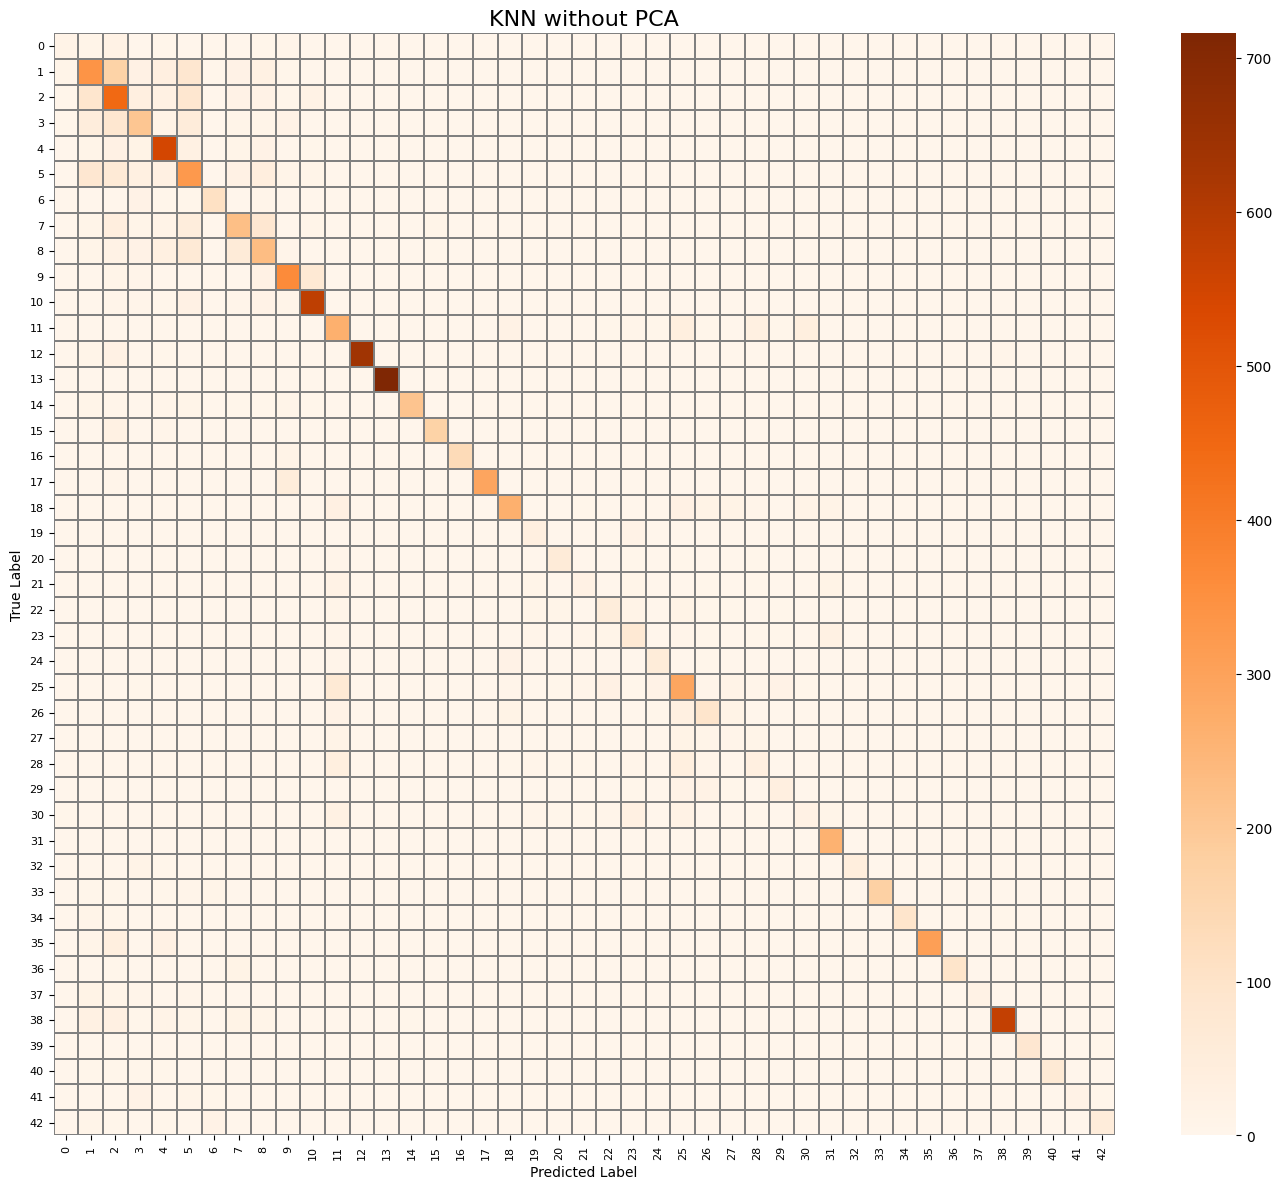

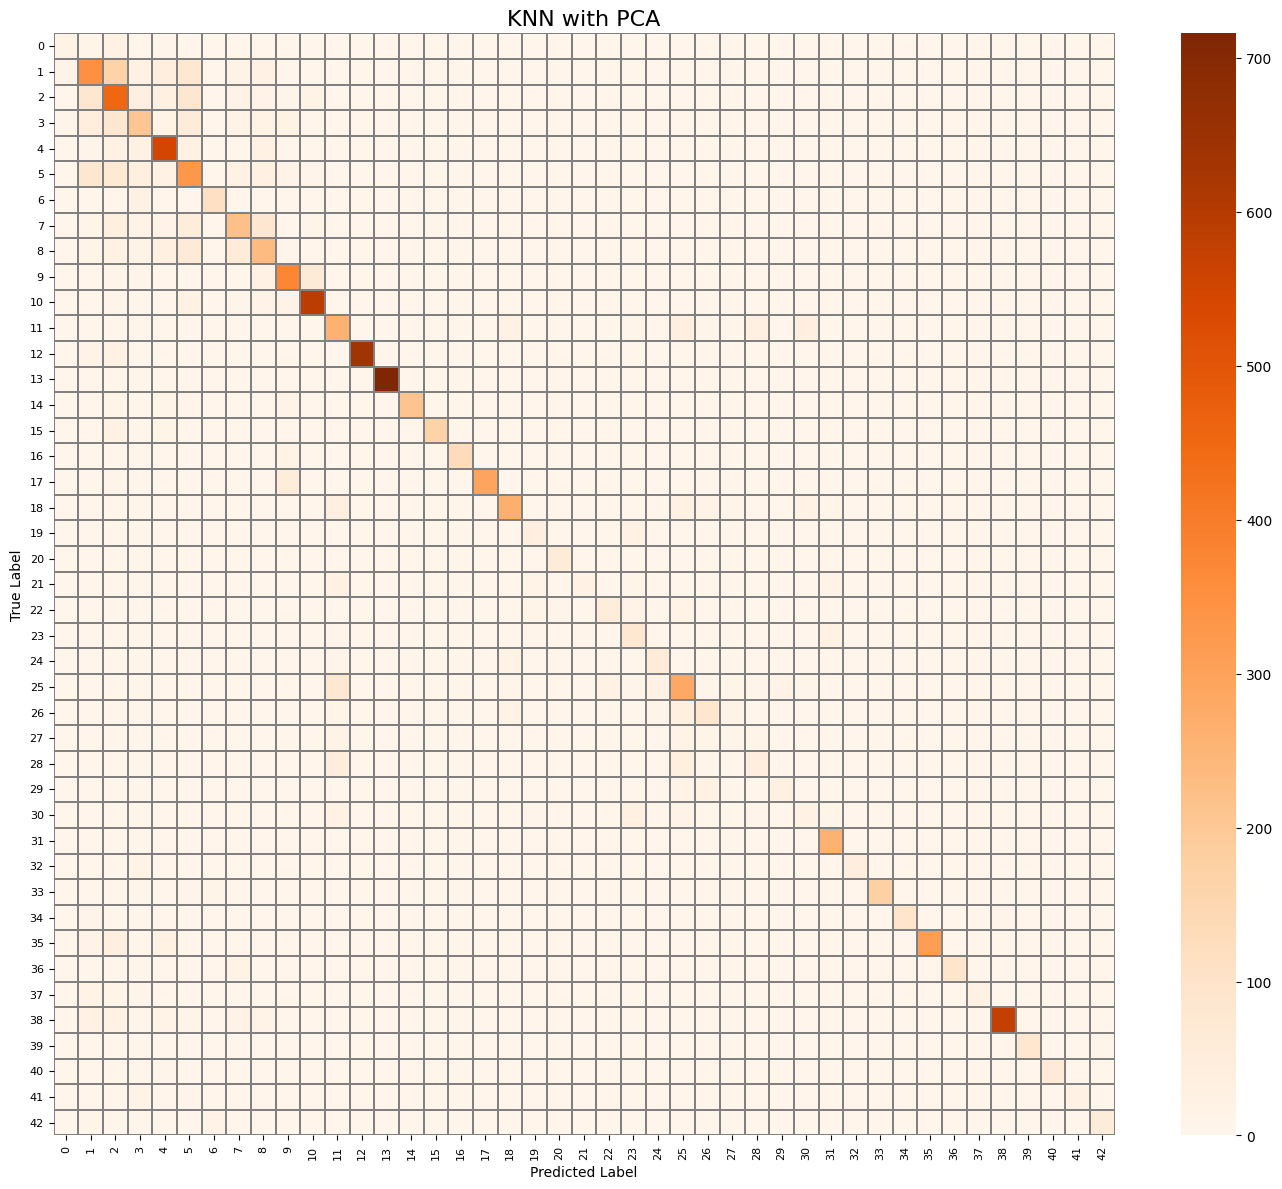

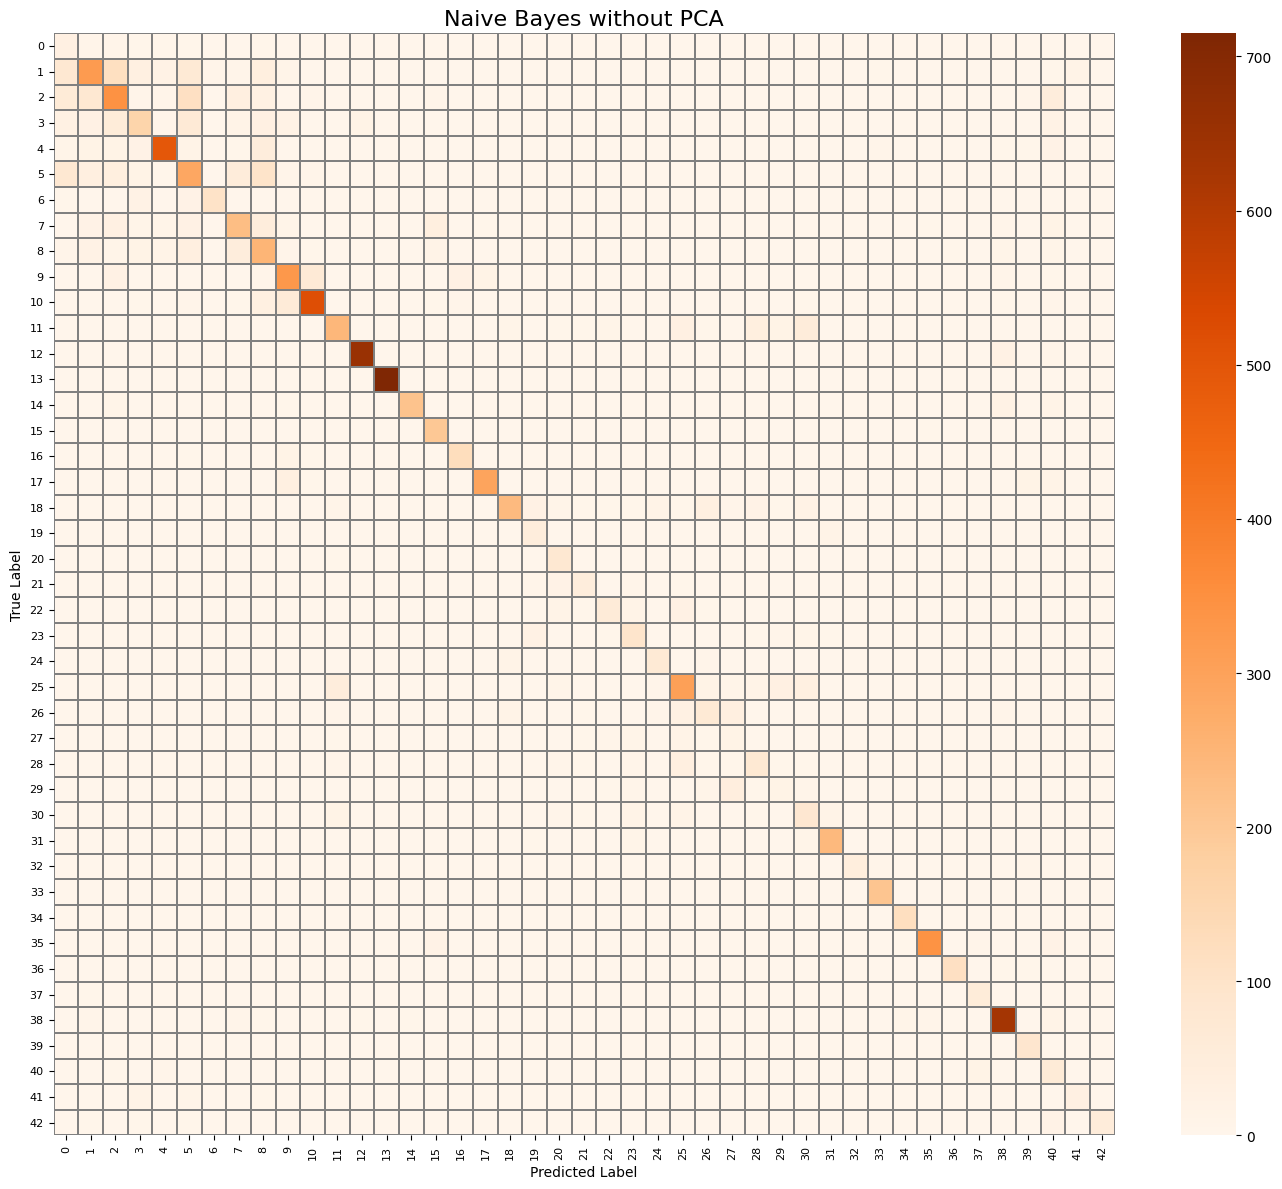

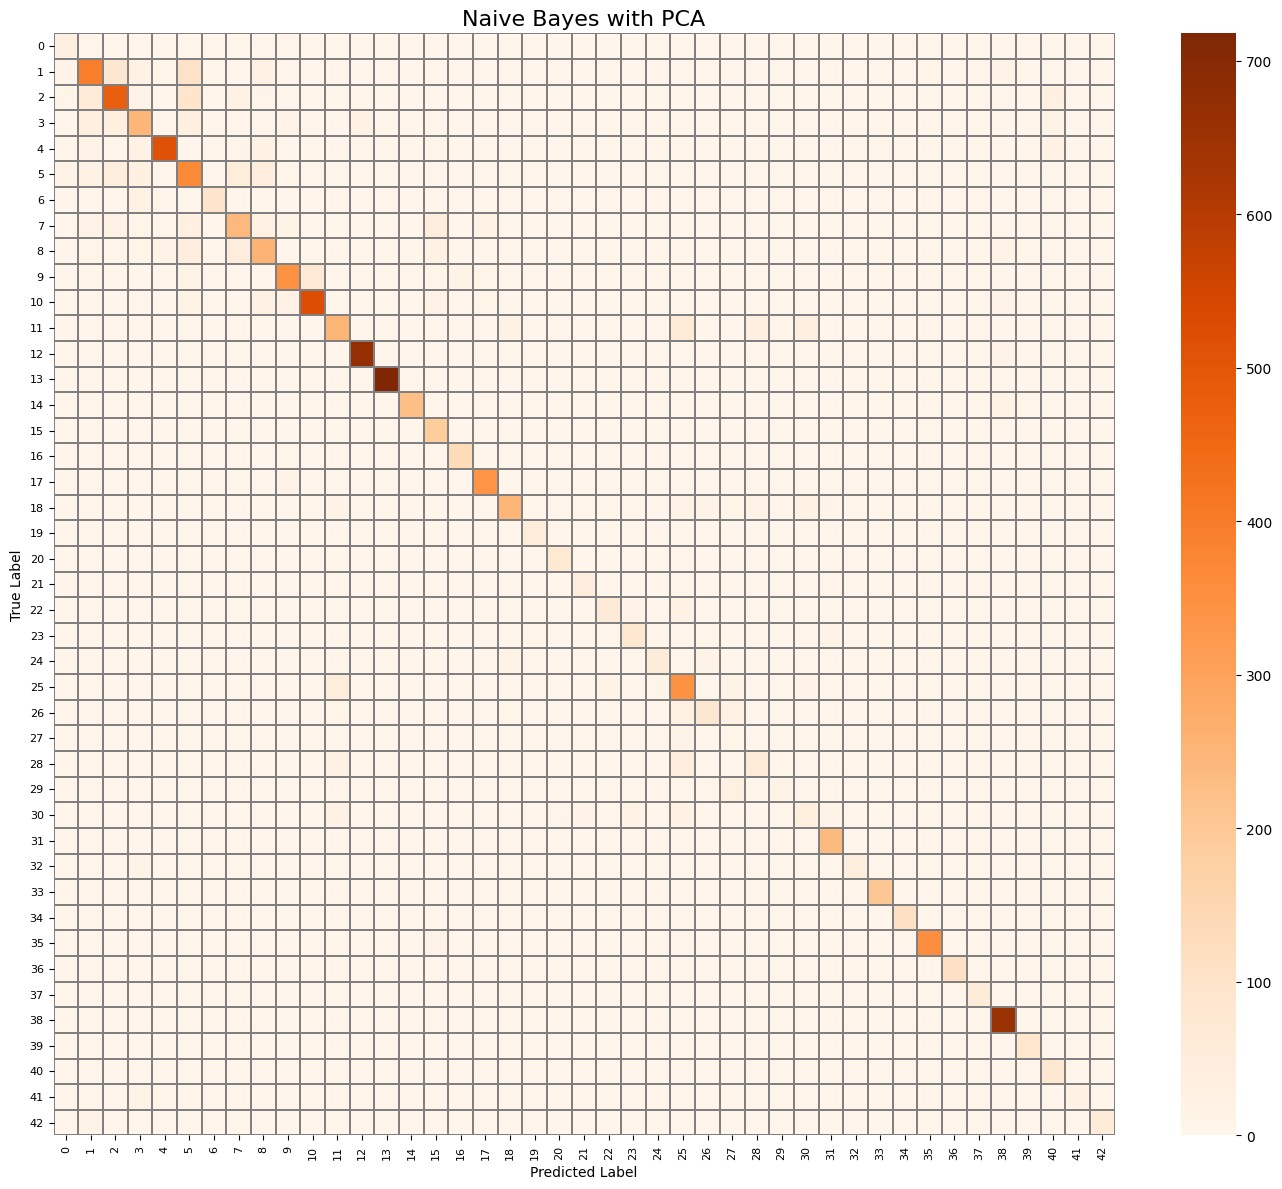

In [ ]:

plot_confusion(y_test, y_KNN_test,     "KNN without PCA")
plot_confusion(y_test, y_KNN_pca_test, "KNN with PCA")
plot_confusion(y_test, y_NB_test,      "Naive Bayes without PCA")
plot_confusion(y_test, y_NB_pca_test,  "Naive Bayes with PCA")

In [8]:
from multiprocessing import Pool

def load_single(fp, size):
    img = Image.open(fp).resize(size)
    img_array = np.array(img)

    if img_array.ndim == 2:
        img_array = np.stack([img_array] * 3, axis=-1)

    if img_array.shape[-1] == 4:
        img_array = img_array[:, :, :3]

    return img_array

def load_images(df, size=(32, 32)):
    with Pool() as p:
        images = p.starmap(load_single, [(fp, size) for fp in df['filepath']])
    return np.array(images) / 255.0      

x_train_img = load_images(train_df)
x_val_img   = load_images(val_df)
x_test_img  = load_images(test_df)

print(f"Train images : {x_train_img.shape}")
print(f"Val images : {x_val_img.shape}")
print(f"Test images : {x_test_img.shape}")

Train images : (25093, 32, 32, 3)
Val images : (6274, 32, 32, 3)
Test images : (12630, 32, 32, 3)


In [10]:
def CNN_Model(num_classes=43):
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model



def CNN_Deep_Model(num_classes=43):
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model



def CNN_K5(num_classes=43):
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, (5,5), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        layers.Conv2D(64, (5,5), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

In [18]:
models_dict = {
    "CNN_Model": CNN_Model(),
    "CNN_Deep_Model": CNN_Deep_Model(),
    "CNN_K5": CNN_K5()
}

h = {}
trained = {}
for name, model in models_dict.items():
    print(f"\nTraining {name} ")

    model.compile(
        optimizer=keras.optimizers.Adam(),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        x_train_img, y_train,
        epochs=10,
        batch_size=64,
        validation_data=(x_test_img, y_test),
        verbose=1
    )

    h[name] = history
    trained[name] = model


Training CNN_Model 
Epoch 1/10
393/393 ━━━━━━━━━━━━━━━━━━━━ 23s 41ms/step - accuracy: 0.5897 - loss: 1.5347 - val_accuracy: 0.7870 - val_loss: 0.8462
Epoch 2/10
393/393 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9139 - loss: 0.3099 - val_accuracy: 0.8511 - val_loss: 0.6219
Epoch 3/10
393/393 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9609 - loss: 0.1492 - val_accuracy: 0.8660 - val_loss: 0.6772
Epoch 4/10
393/393 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9758 - loss: 0.0922 - val_accuracy: 0.8971 - val_loss: 0.5190
Epoch 5/10
393/393 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9810 - loss: 0.0687 - val_accuracy: 0.8847 - val_loss: 0.5714
Epoch 6/10
393/393 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9876 - loss: 0.0470 - val_accuracy: 0.9085 - val_loss: 0.4966
Epoch 7/10
393/393 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9900 - loss: 0.0379 - val_accuracy: 0.9103 - val_loss: 0.5056
Epoch 8/10
393/393 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9933 - l

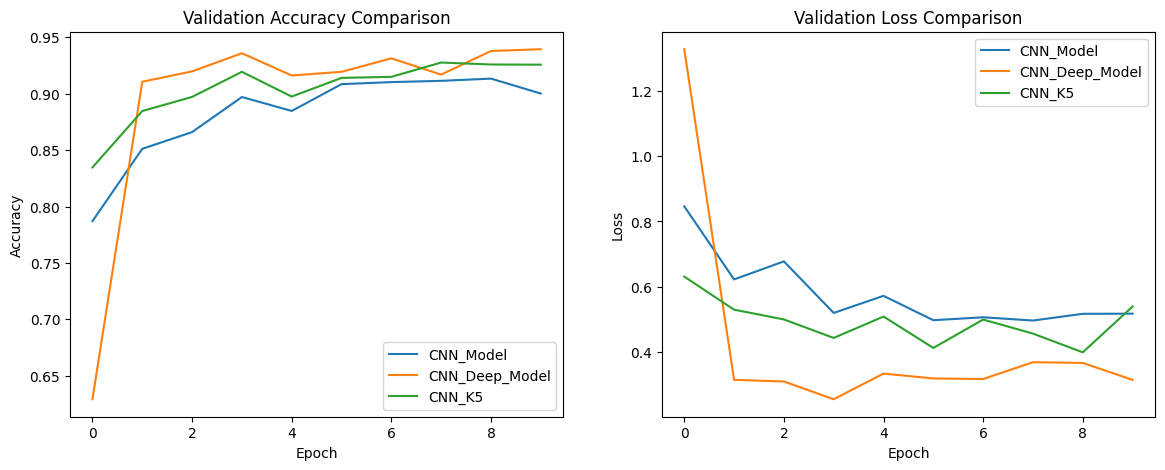

In [19]:
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
for name, x in h.items():
    plt.plot(x.history['val_accuracy'], label=name)
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.subplot(1,2,2)
for name, x in h.items():
    plt.plot(x.history['val_loss'], label=name)
plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

Best Model: CNN_Deep_Model
395/395 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step


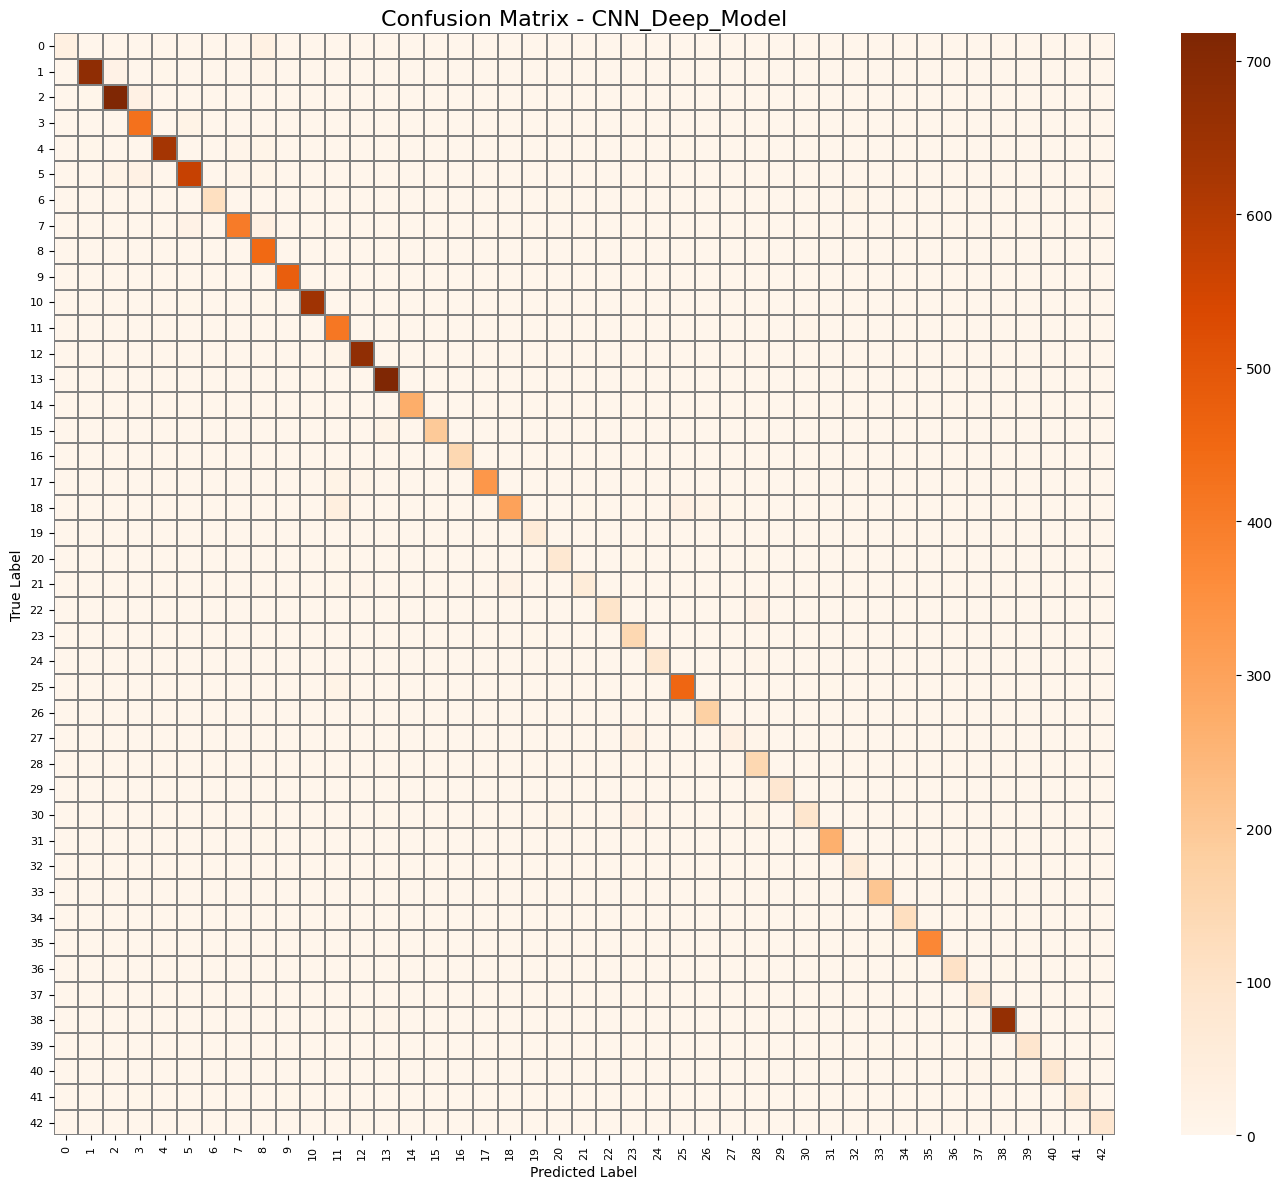

In [20]:
best_model_name = max(h, key=lambda x: max(h[x].history['val_accuracy']))
best_model = trained[best_model_name]

print("Best Model:", best_model_name)

y_pred = best_model.predict(x_test_img)
y_pred_classes = np.argmax(y_pred, axis=1)

plot_confusion(
    y_test,
    y_pred_classes,
    f"Confusion Matrix - {best_model_name}"
)

In [9]:
def build_cnn(num_classes=43):
    model = models.Sequential()
    optimizer = keras.optimizers.Adam(learning_rate=0.001)

    # first block
    model.add(layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu', 
                             padding='same', input_shape=(32, 32, 3)))
    model.add(layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu', 
                             padding='same'))
    model.add(layers.MaxPooling2D(pool_size=(2,2)))

    # second block
    model.add(layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu', 
                             padding='same'))
    model.add(layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu', 
                             padding='same'))
    model.add(layers.MaxPooling2D(pool_size=(2,2)))

    # third block
    model.add(layers.Conv2D(filters=128, kernel_size=(3,3), activation='relu', 
                              padding='same'))
    model.add(layers.Conv2D(filters=128, kernel_size=(3,3), activation='relu', 
                              padding='same'))
    model.add(layers.GlobalAveragePooling2D())

    model.add(layers.Flatten())
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dense(num_classes, activation='softmax'))


    return model

model = build_cnn()
model.summary()

/home/engshadow/.local/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 331,083 (1.26 MB)

 Trainable params: 331,083 (1.26 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
histories_cnn = {}

for name, optimizer in [
    ('Adam', keras.optimizers.Adam()),
    ('SGD',  keras.optimizers.SGD(0.01, momentum=0.9))
]:
    m = build_cnn()
    m.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

    hist = m.fit(
        x_train_img, y_train,
        epochs=40,
        batch_size=64,
        validation_data=(x_val_img, y_val),  
        verbose=1
    )
    histories_cnn[name] = (m, hist)

    test_loss, test_acc = m.evaluate(x_test_img, y_test, verbose=0)
    print(f"\nCNN ({name}) Test Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")


Epoch 1/40
491/491 ━━━━━━━━━━━━━━━━━━━━ 72s 74ms/step - accuracy: 0.1553 - loss: 3.0076 - val_accuracy: 0.3935 - val_loss: 1.8406
Epoch 2/40
491/491 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.5762 - loss: 1.2248 - val_accuracy: 0.7467 - val_loss: 0.7287
Epoch 3/40
491/491 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.8651 - loss: 0.4094 - val_accuracy: 0.8425 - val_loss: 0.5092
Epoch 4/40
491/491 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9467 - loss: 0.1704 - val_accuracy: 0.9686 - val_loss: 0.1071
Epoch 5/40
491/491 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9705 - loss: 0.0969 - val_accuracy: 0.9433 - val_loss: 0.1848
Epoch 6/40
491/491 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.9787 - loss: 0.0675 - val_accuracy: 0.9793 - val_loss: 0.0811
Epoch 7/40
491/491 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.9847 - loss: 0.0491 - val_accuracy: 0.9802 - val_loss: 0.0668
Epoch 8/40
491/491 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9884 - loss: 0.0392 - val_acc

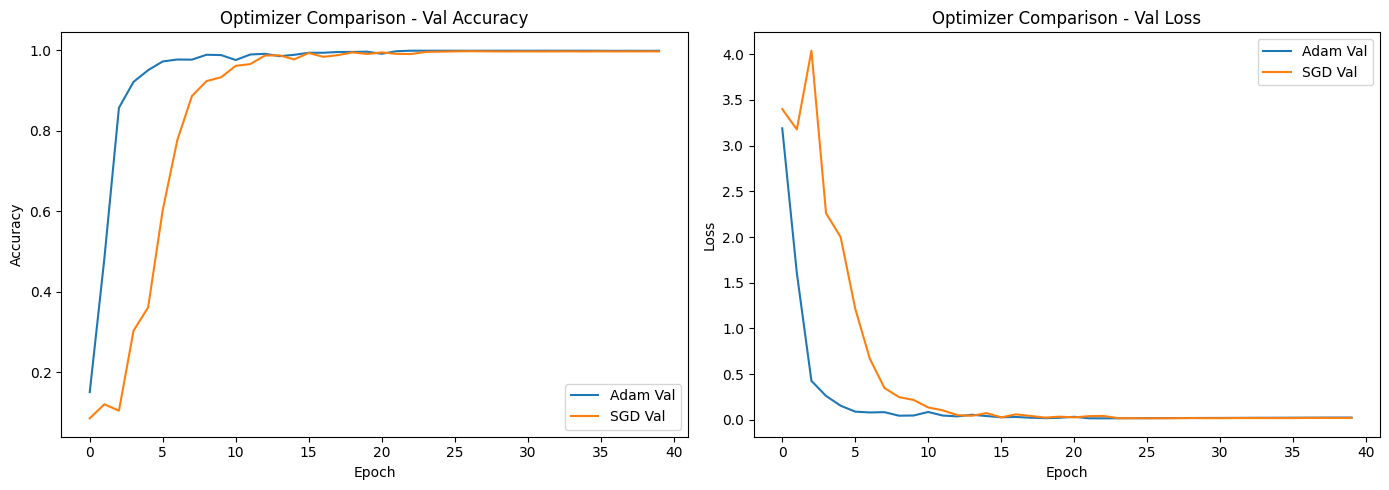

In [44]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
for name, (_, h) in histories_cnn.items():
    plt.plot(h.history['val_accuracy'], label=f'{name} Val')
plt.title('Optimizer Comparison - Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
for name, (_, h) in histories_cnn.items():
    plt.plot(h.history['val_loss'], label=f'{name} Val')
plt.title('Optimizer Comparison - Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [10]:


def gaussian_noise(images, noise_factor=0.3):
    noisy = images + noise_factor * np.random.normal(
        loc=0.0, scale=1.0, size=images.shape)
    return np.clip(noisy, 0., 1.)

def salt_pepper(images, dropout_rate=0.1):
    noisy = np.copy(images)
    mask  = np.random.binomial(1, 1 - dropout_rate, size=images.shape)
    return noisy * mask

x_train_noisy = gaussian_noise(x_train_img, noise_factor=0.2)
x_train_noisy = salt_pepper(x_train_noisy, dropout_rate=0.1)

x_val_noisy   = gaussian_noise(x_val_img, noise_factor=0.2)
x_val_noisy   = salt_pepper(x_val_noisy, dropout_rate=0.1)

x_test_noisy = gaussian_noise(x_test_img, noise_factor=0.2)
x_test_noisy = salt_pepper(x_test_noisy, dropout_rate=0.1)


print(f"Noisy train shape : {x_train_noisy.shape}")
print(f"Noisy val shape : {x_val_noisy.shape}")
print(f"Noisy test shape : {x_test_noisy.shape}")

Noisy train shape : (31367, 32, 32, 3)
Noisy val shape : (7842, 32, 32, 3)
Noisy test shape : (12630, 32, 32, 3)


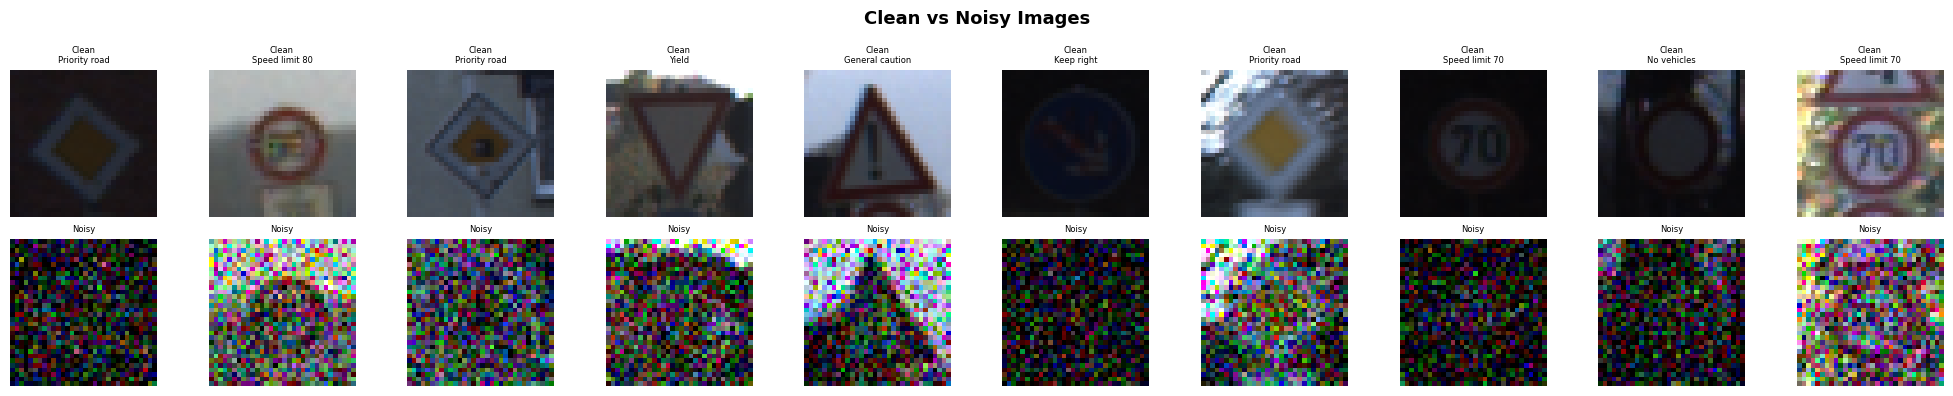

In [11]:
fig, axes = plt.subplots(2, 10, figsize=(20, 4))
for i in range(10):
    axes[0, i].imshow(x_train_img[i])
    axes[0, i].set_title(f"Clean\n{CLASS_NAMES[y_train[i]]}", fontsize=6)
    axes[0, i].axis('off')

    axes[1, i].imshow(x_train_noisy[i])
    axes[1, i].set_title("Noisy", fontsize=6)
    axes[1, i].axis('off')

plt.suptitle('Clean vs Noisy Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [12]:
def build_cnn_autoencoder(input_shape=(32, 32, 3)):
    inputs = layers.Input(shape=input_shape)

    # ENCODER 
    x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D(2, 2)(x)                  

    x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2, 2)(x)                 

    x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
    encoded = layers.MaxPooling2D(2, 2)(x)             #(bottleneck)

    # DECODER 
    x = layers.Conv2DTranspose(128, (3,3), activation='relu',
                                strides=2, padding='same')(encoded)   
    x = layers.Conv2DTranspose(64,  (3,3), activation='relu',
                                strides=2, padding='same')(x)        
    x = layers.Conv2DTranspose(32,  (3,3), activation='relu',
                                strides=2, padding='same')(x)        

    decoded = layers.Conv2D(3, (3,3), activation='sigmoid',
                             padding='same')(x)                       

    autoencoder = keras.Model(inputs, decoded, name='cnn_autoencoder')
    return autoencoder

autoencoder = build_cnn_autoencoder()
autoencoder.summary()


# Compile the model
autoencoder.compile(
    optimizer='adam',
    loss='mse',
)

Model: "cnn_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 8, 8, 128)      │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 16, 16, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 32, 32, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,955 (1.27 MB)

 Trainable params: 333,955 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history_ae = autoencoder.fit(
    x_train_noisy, x_train_img,          
    epochs=40,
    batch_size=32,
    shuffle=True,
    validation_data=(x_val_noisy, x_val_img),
    verbose=1
)

Epoch 1/40
981/981 ━━━━━━━━━━━━━━━━━━━━ 78s 43ms/step - loss: 0.0162 - val_loss: 0.0105
Epoch 2/40
981/981 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step - loss: 0.0083 - val_loss: 0.0075
Epoch 3/40
981/981 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 0.0068 - val_loss: 0.0065
Epoch 4/40
981/981 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - loss: 0.0060 - val_loss: 0.0060
Epoch 5/40
981/981 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 0.0055 - val_loss: 0.0055
Epoch 6/40
981/981 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step - loss: 0.0052 - val_loss: 0.0051
Epoch 7/40
981/981 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 0.0049 - val_loss: 0.0048
Epoch 8/40
981/981 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step - loss: 0.0047 - val_loss: 0.0048
Epoch 9/40
981/981 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 0.0045 - val_loss: 0.0046
Epoch 10/40
981/981 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - loss: 0.0044 - val_loss: 0.0045
Epoch 11/40
981/981 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step - loss: 0.0043 - val_loss: 0.0044
Epoch 12/40
981/981 ━━━━━━━━━━

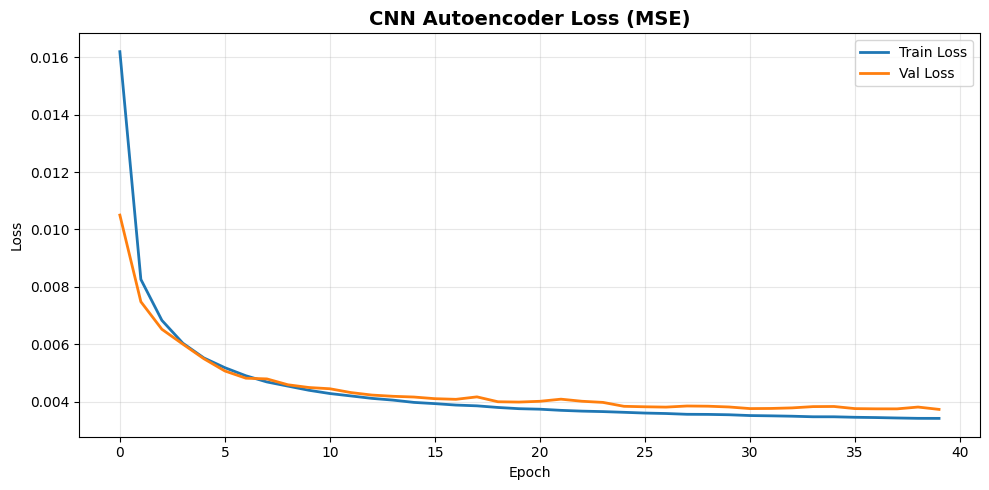

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(history_ae.history['loss'],     label='Train Loss', linewidth=2)
plt.plot(history_ae.history['val_loss'], label='Val Loss',   linewidth=2)
plt.title('CNN Autoencoder Loss (MSE)', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Generating reconstructed features
981/981 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step
246/246 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step
395/395 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step


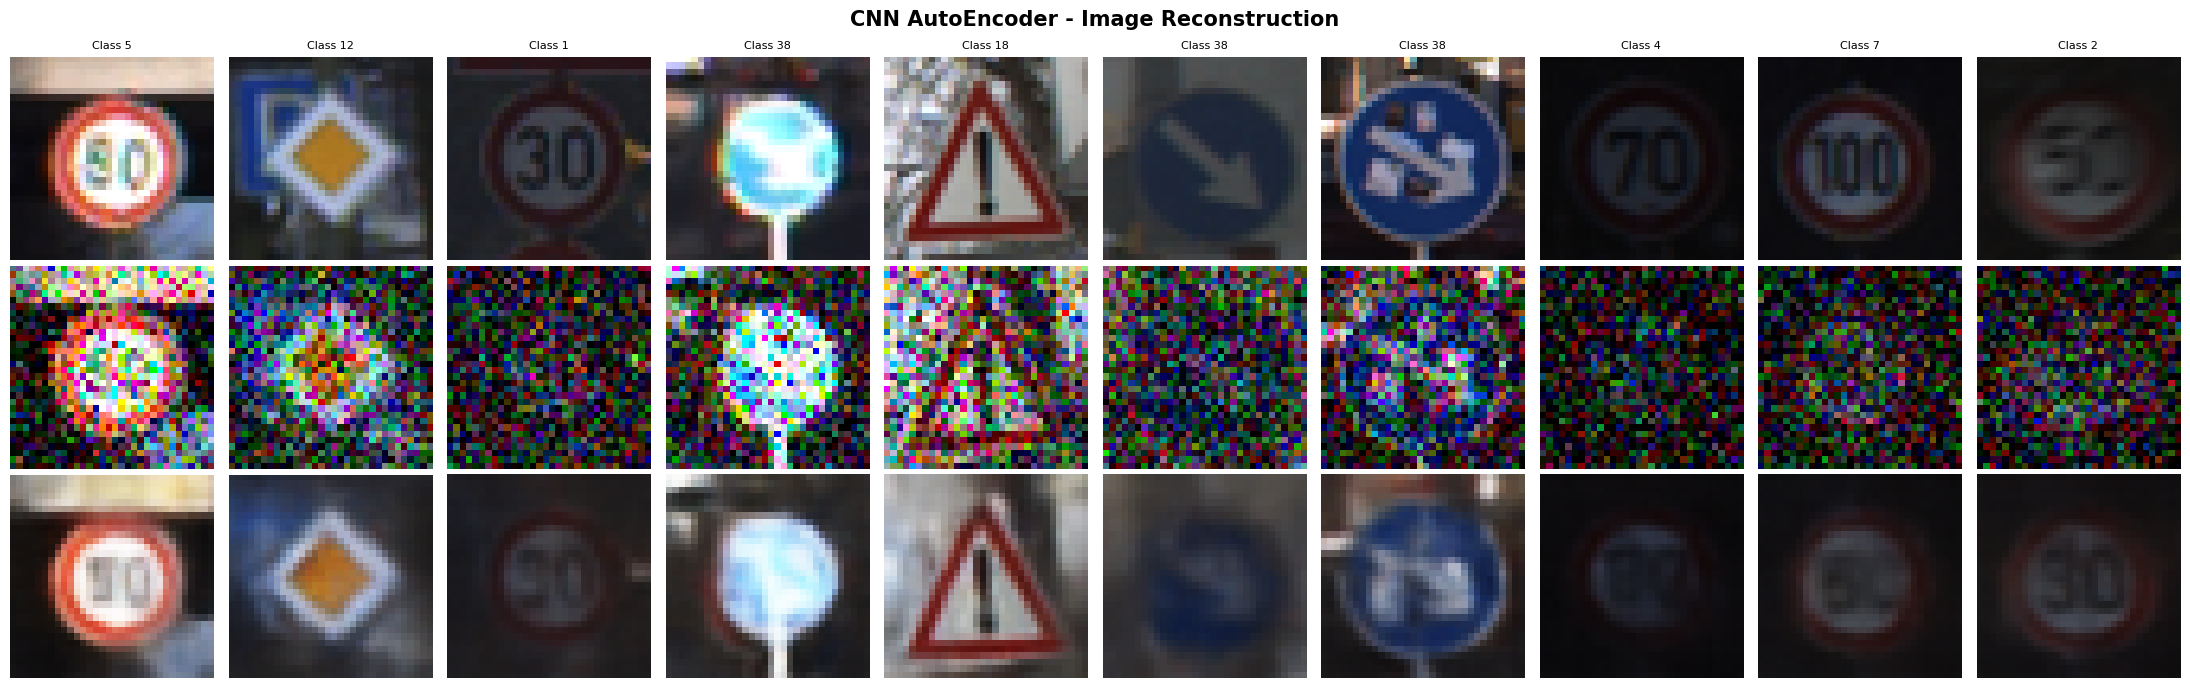

In [16]:
print("\nGenerating reconstructed features")

x_train_reconstructed = autoencoder.predict(x_train_noisy)
x_val_reconstructed   = autoencoder.predict(x_val_noisy)
x_test_reconstructed  = autoencoder.predict(x_test_noisy)

n_samples = 10
sample_indices = np.random.choice(len(x_test_img), n_samples, replace=False)

fig, axes = plt.subplots(3, n_samples, figsize=(22, 7))

for i, idx in enumerate(sample_indices):
    # Clean images
    axes[0, i].imshow(x_test_img[idx])
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_ylabel('Clean',
                               fontsize=10, fontweight='bold')

    # Noisy images
    axes[1, i].imshow(x_test_noisy[idx])
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_ylabel('Noisy',
                               fontsize=10, fontweight='bold')

    # Reconstructed images
    axes[2, i].imshow(x_test_reconstructed[idx])
    axes[2, i].axis('off')
    if i == 0:
        axes[2, i].set_ylabel('Reconstructed',
                               fontsize=10, fontweight='bold')

    axes[0, i].set_title(f'Class {y_test[idx]}', fontsize=8)

plt.suptitle('CNN AutoEncoder - Image Reconstruction',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


In [17]:
mse_train = np.mean((x_train_img - x_train_reconstructed) ** 2)
mse_val   = np.mean((x_val_img   - x_val_reconstructed)   ** 2)
mse_test  = np.mean((x_test_img  - x_test_reconstructed)  ** 2)

print(f"\n{'='*60}")
print(f"CNN AUTOENCODER - Image Reconstruction Performance")
print(f"{'='*60}")
print(f"Train MSE : {mse_train:.6f}")
print(f"Val   MSE : {mse_val:.6f}")
print(f"Test  MSE : {mse_test:.6f}")
print(f"{'='*60}")


CNN AUTOENCODER - Image Reconstruction Performance
Train MSE : 0.003394
Val   MSE : 0.003729
Test  MSE : 0.003880


In [ ]:
import joblib
import json

# Paths
base_path = ""
model_path = os.path.join(base_path, "models")
os.makedirs(model_path, exist_ok=True)

# 1. Save Autoencoder Model
autoencoder.save(os.path.join(model_path, "autoencoder.h5"))

# 2. Save Encoder Only (Feature Extractor)
encoder = keras.Model(autoencoder.input, autoencoder.layers[3].output)
encoder.save(os.path.join(model_path, "encoder.h5"))

# 3. Save Scaler
joblib.dump(scaler, os.path.join(model_path, "scaler.pkl"))

# 4. Save Reconstructed Features
features_path = os.path.join(base_path, "features")

np.save(os.path.join(features_path, "x_train_reconstructed.npy"), x_train_reconstructed)
np.save(os.path.join(features_path, "x_test_reconstructed.npy"), x_test_reconstructed)

# 5. Save Noisy Data
np.save(os.path.join(features_path, "x_train_noisy.npy"), x_train_noisy)
np.save(os.path.join(features_path, "x_test_noisy.npy"), x_test_noisy)

# 6. Save Training History
with open(os.path.join(base_path, "history.json"), "w") as f:
    json.dump(history_ae.history, f)

# 7. Save Metrics
with open(os.path.join(base_path, "results.txt"), "w") as f:
    f.write(f"Train MSE: {mse_train}\n")
    f.write(f"Test MSE: {mse_test}\n")

print("All new components saved successfully!")

All new components saved successfully!
